<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import kagglehub
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.


In [36]:
import pandas as pd

df = pd.read_csv(f'{path}/winequality-red.csv')
display(df.sample(3))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
696,7.0,0.650,0.02,2.10,0.066,8.0,25.0,0.99720,3.47,0.67,9.5,6
914,7.3,0.305,0.39,1.20,0.059,7.0,11.0,0.99331,3.29,0.52,11.5,6
357,10.5,0.420,0.66,2.95,0.116,12.0,29.0,0.99700,3.24,0.75,11.7,7


In [37]:
df['quality']

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5


In [38]:
import numpy as np
import matplotlib as plt
import seaborn as sns

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [60]:
columns_to_drop = ['fixed acidity', 'citric acid', 'chlorides', 'residual sugar', 'density']
df = df.drop(columns=columns_to_drop)
display(df.head())

,volatile acidity,free sulfur dioxide,total sulfur dioxide,pH,sulphates,alcohol,quality
0,0.70,11.0,34.0,3.51,0.56,9.4,5
1,0.88,25.0,67.0,3.20,0.68,9.8,5
2,0.76,15.0,54.0,3.26,0.65,9.8,5
3,0.28,17.0,60.0,3.16,0.58,9.8,6
4,0.70,11.0,34.0,3.51,0.56,9.4,5


In [61]:
df.isnull().sum()

,0
volatile acidity,0
free sulfur dioxide,0
total sulfur dioxide,0
pH,0
sulphates,0
alcohol,0
quality,0


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [62]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('quality', axis=1), df['quality'], test_size=0.2, random_state=42)

In [44]:
x_test.shape, x_train.shape, y_test.shape, y_train.shape

((1279, 11), (320, 11), (1279,), (320,))

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor # Changed from DecisionTreeClassifier

# Define the base pipeline with a scaler and a Decision Tree Regressor
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=42)) # Changed to regressor
])

# Define the parameter grid for the DecisionTreeRegressor
param_grid = {
    'regressor__max_depth': [3, 5, 7, None],  # None means no limit
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error'] # Regression criteria
}

# Create a GridSearchCV object that wraps the pipeline
# The 'pipeline' variable will now hold the GridSearchCV object
pipeline = GridSearchCV(estimator=base_pipeline,
                        param_grid=param_grid,
                        cv=5, # 5-fold cross-validation
                        scoring='neg_mean_squared_error', # Changed to a regression metric
                        n_jobs=-1, # Use all available cores
                        verbose=1) # Display progress

In [63]:
pipeline.fit(x_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regressor',
                                        DecisionTreeRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__criterion': ['squared_error',
                                                  'friedman_mse',
                                                  'absolute_error'],
                         'regressor__max_depth': [3, 5, 7, None],
                         'regressor__min_samples_leaf': [1, 2, 4],
                         'regressor__min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error', verbose=1)

In [64]:
print("Best Parameters found (after feature removal):", pipeline.best_params_)
print("Best Cross-Validation Score (Negative MSE, after feature removal):", pipeline.best_score_)

Best Parameters found (after feature removal): {'regressor__criterion': 'squared_error', 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2}
Best Cross-Validation Score (Negative MSE, after feature removal): -0.4679026337146919


In [65]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
import numpy as np

# Evaluate the model with the best estimator (regressor)
y_pred_tuned = pipeline.best_estimator_.predict(x_test)

# Round predictions to nearest integer for interpretation as quality scores, if desired
y_pred_tuned_rounded = np.round(y_pred_tuned).astype(int)

print("Mean Squared Error (tuned model, after feature removal):", mean_squared_error(y_test, y_pred_tuned))
print("R-squared (tuned model, after feature removal):", r2_score(y_test, y_pred_tuned))

# If you still want to see 'accuracy' in terms of rounded predictions vs actual classes
# This is not a standard regression metric, but can be informative for discrete targets
print("\nAccuracy Score (rounded predictions vs actual, tuned model, after feature removal):", accuracy_score(y_test, np.clip(y_pred_tuned_rounded, y_test.min(), y_test.max())))
print("\nConfusion Matrix (rounded predictions, tuned model, after feature removal):\n", confusion_matrix(y_test, np.clip(y_pred_tuned_rounded, y_test.min(), y_test.max())))
print("\nClassification Report (rounded predictions, tuned model, after feature removal):\n", classification_report(y_test, np.clip(y_pred_tuned_rounded, y_test.min(), y_test.max())))


Mean Squared Error (tuned model, after feature removal): 0.41973281667286527
R-squared (tuned model, after feature removal): 0.35772141802326096

Accuracy Score (rounded predictions vs actual, tuned model, after feature removal): 0.5625

Confusion Matrix (rounded predictions, tuned model, after feature removal):
 [[ 0  0  0  1  0  0]
 [ 0  1  4  5  0  0]
 [ 0  2 80 48  0  0]
 [ 0  0 36 91  5  0]
 [ 0  0  1 33  8  0]
 [ 0  0  0  3  2  0]]

Classification Report (rounded predictions, tuned model, after feature removal):
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.10      0.15        10
           5       0.66      0.62      0.64       130
           6       0.50      0.69      0.58       132
           7       0.53      0.19      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.56       320
   macro avg       0.34      0.27      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


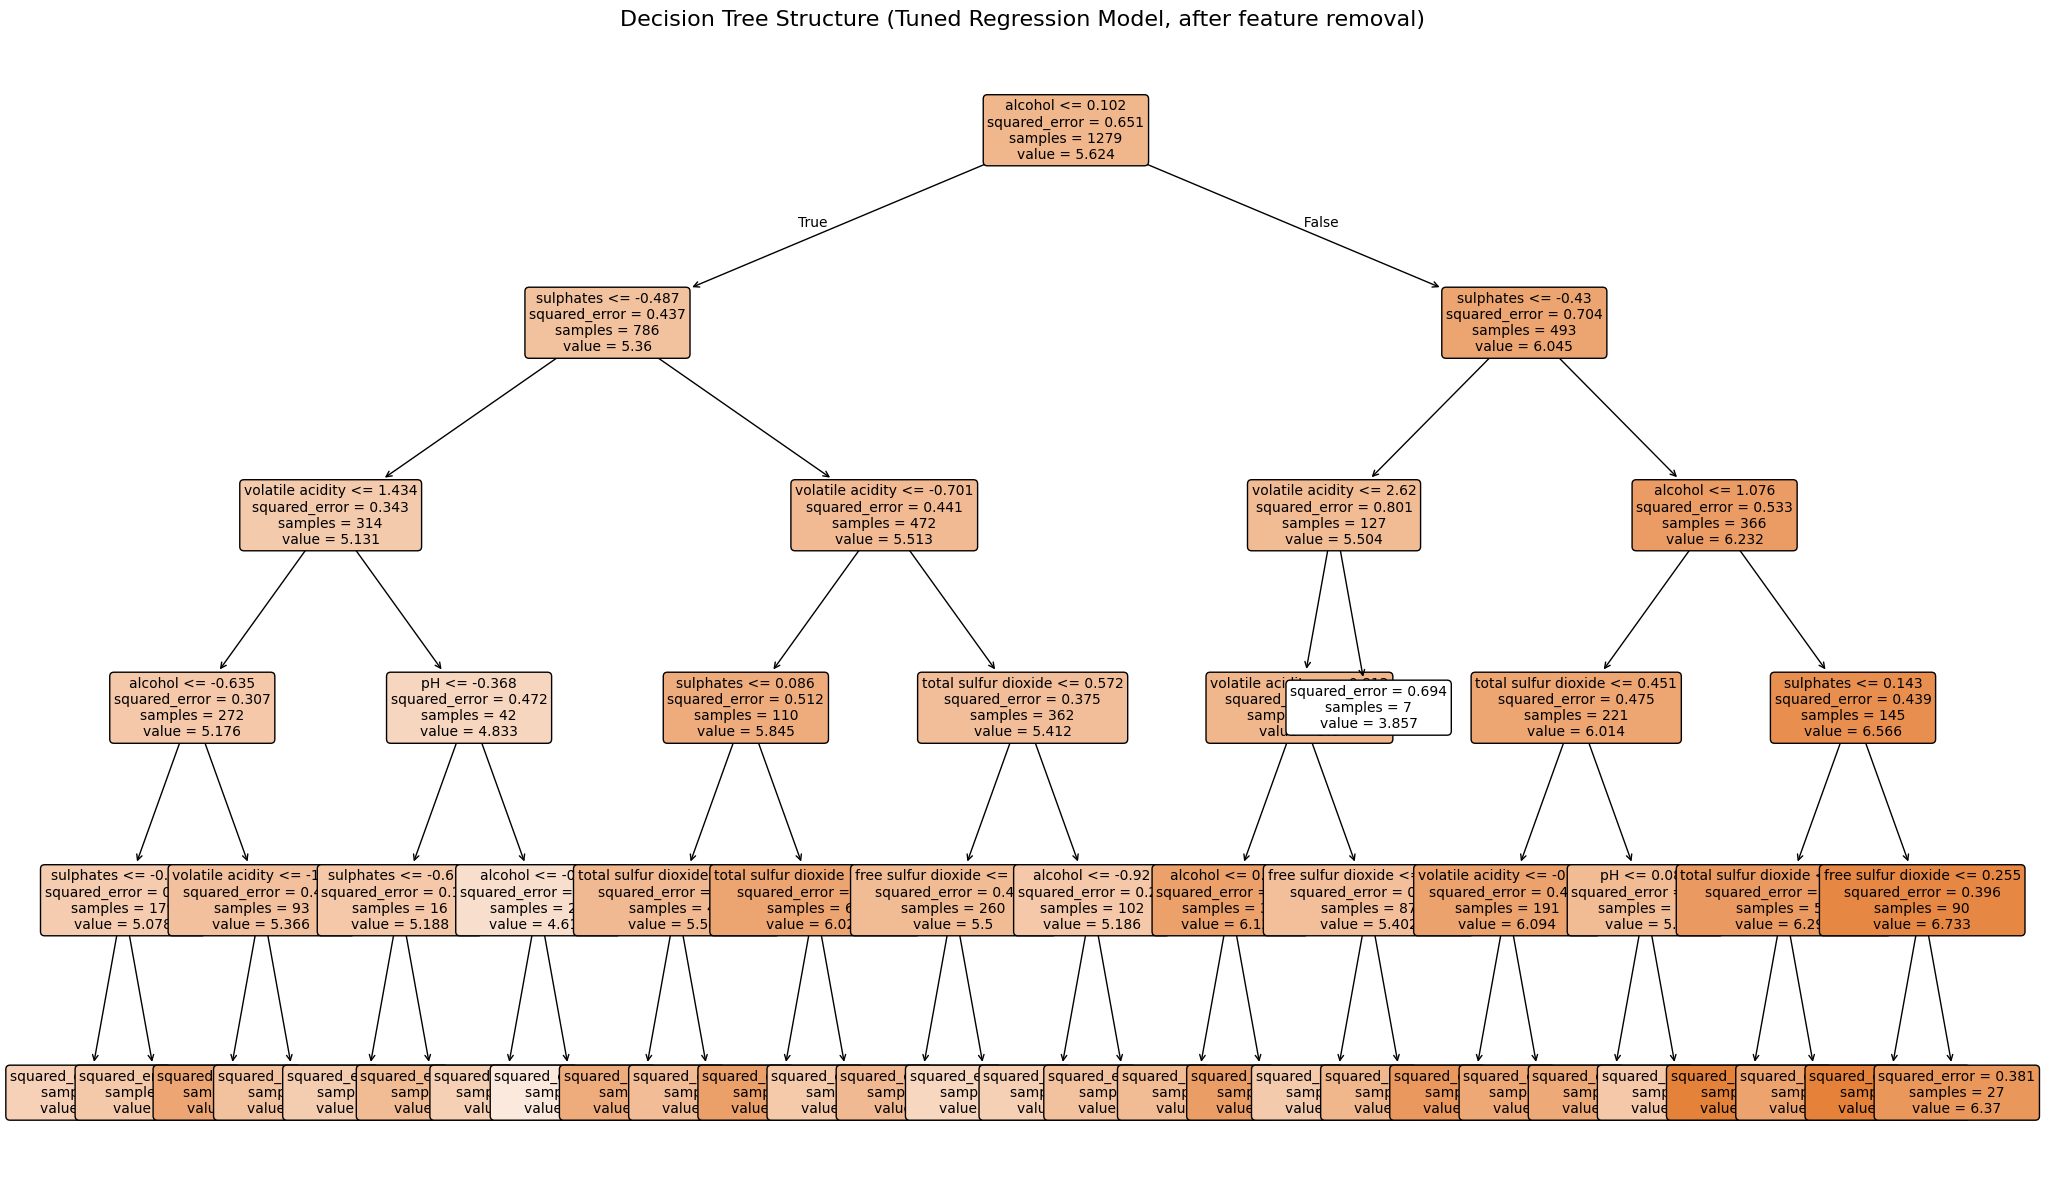

In [67]:
import matplotlib.pyplot as plt

# Get the best DecisionTreeRegressor from the pipeline
best_tree_model = pipeline.best_estimator_.named_steps['regressor']

# Get feature names from x_train (updated after column removal)
feature_names = x_train.columns.tolist()

# Get class names from y_train (unique quality levels) - still useful for visualization as 'value' display
class_names = [str(int(c)) for c in sorted(y_train.unique())]

plt.figure(figsize=(25, 15))
plot_tree(best_tree_model,
          feature_names=feature_names,
          class_names=class_names, # Use for class display in nodes, even for regression
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (Tuned Regression Model, after feature removal)', fontsize=16)
plt.show()

/tmp/ipykernel_621/1031953914.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


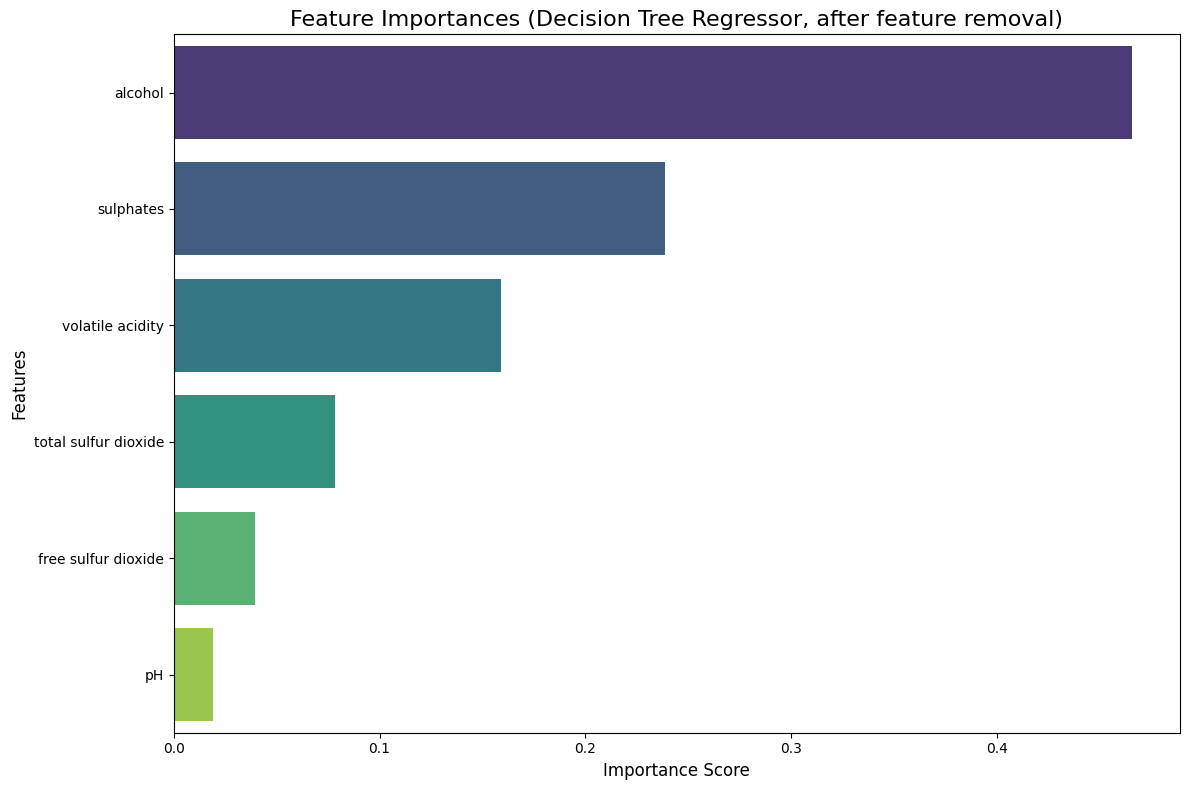

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best DecisionTreeRegressor from the pipeline
best_regressor = pipeline.best_estimator_.named_steps['regressor']

# Get feature importances
importances = best_regressor.feature_importances_

# Create a pandas Series for better visualization, using updated x_train.columns
feature_importances = pd.Series(importances, index=x_train.columns).sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances (Decision Tree Regressor, after feature removal)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

# Predicting using the *tuned* regressor after feature removal
y_pred_regressor = pipeline.best_estimator_.predict(x_test)

print("Mean Squared Error (tuned regressor, after feature removal):", mean_squared_error(y_test, y_pred_regressor))
print("R-squared (tuned regressor, after feature removal):", r2_score(y_test, y_pred_regressor))

Mean Squared Error (tuned regressor, after feature removal): 0.41973281667286527
R-squared (tuned regressor, after feature removal): 0.35772141802326096


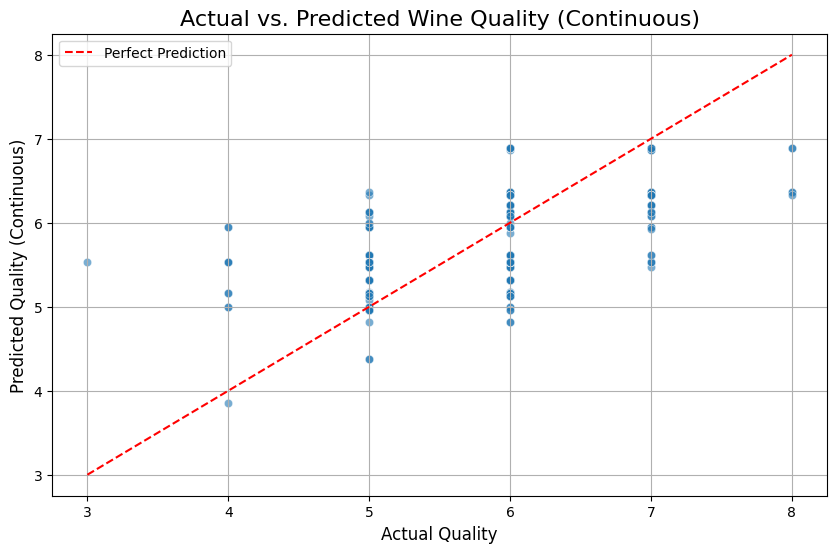

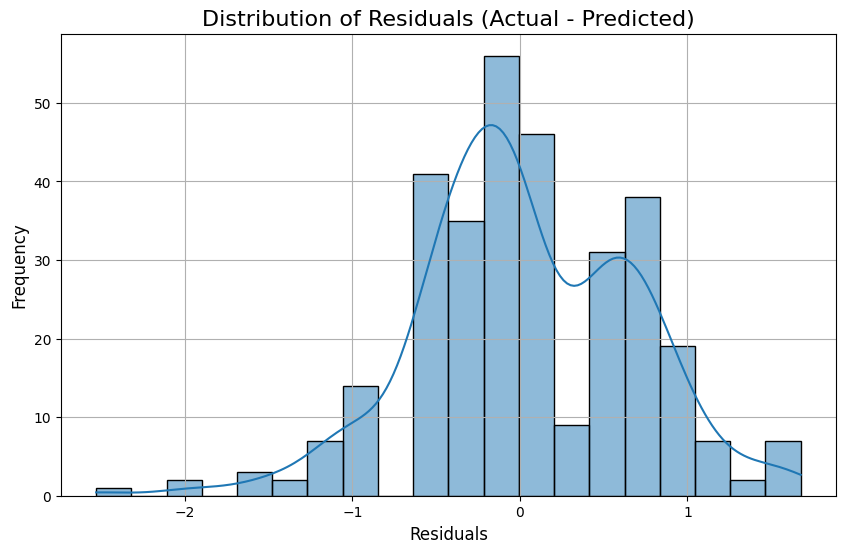

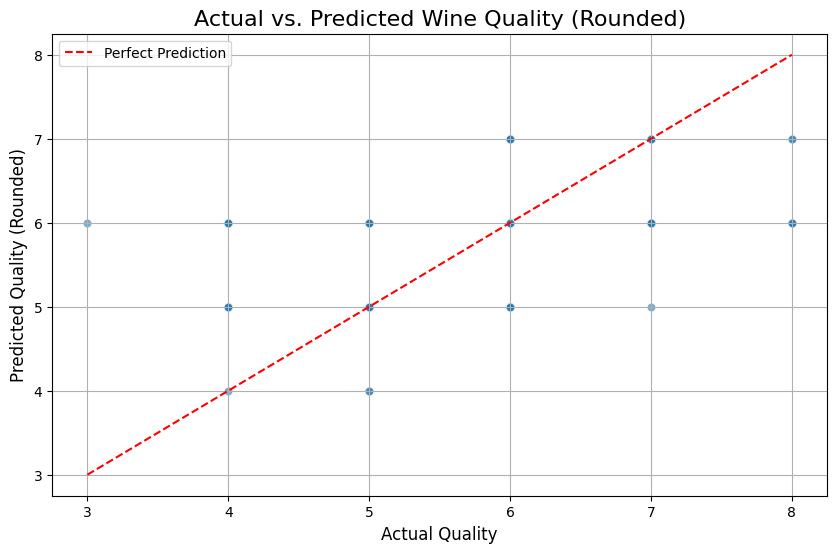

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting
results_df = pd.DataFrame({'Actual Quality': y_test, 'Predicted Quality (Continuous)': y_pred_tuned, 'Predicted Quality (Rounded)': y_pred_tuned_rounded})

# --- Scatter plot of Actual vs. Predicted (Continuous) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Quality', y='Predicted Quality (Continuous)', data=results_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction') # Perfect prediction line
plt.title('Actual vs. Predicted Wine Quality (Continuous)', fontsize=16)
plt.xlabel('Actual Quality', fontsize=12)
plt.ylabel('Predicted Quality (Continuous)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# --- Distribution of Residuals (Errors) ---
residuals = y_test - y_pred_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=20)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()

# --- Scatter plot of Actual vs. Predicted (Rounded) ---
# This helps to visualize how many rounded predictions match actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Quality', y='Predicted Quality (Rounded)', data=results_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction') # Perfect prediction line
plt.title('Actual vs. Predicted Wine Quality (Rounded)', fontsize=16)
plt.xlabel('Actual Quality', fontsize=12)
plt.ylabel('Predicted Quality (Rounded)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [5]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

# 1. Load the dataset (as in previous steps)
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
df = pd.read_csv(f'{path}/winequality-red.csv')

# 2. Apply feature engineering (drop columns as previously decided)
columns_to_drop = ['fixed acidity', 'citric acid', 'chlorides', 'residual sugar', 'density']
df_processed = df.drop(columns=columns_to_drop)

# 3. Re-split the data to ensure x_test and y_test are defined from the processed df
X = df_processed.drop('quality', axis=1)
y = df_processed['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Re-define and fit the GridSearchCV pipeline
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'regressor__max_depth': [3, 5, 7, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

pipeline = GridSearchCV(estimator=base_pipeline,
                        param_grid=param_grid,
                        cv=5,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1,
                        verbose=0)

pipeline.fit(X_train, y_train)

# 5. Re-predict using the best estimator from the pipeline
y_pred_tuned = pipeline.best_estimator_.predict(X_test)
y_pred_tuned_rounded = np.round(y_pred_tuned).astype(int)

# 6. Create and describe results_df
results_df = pd.DataFrame({
    'Actual Quality': y_test,
    'Predicted Quality (Continuous)': y_pred_tuned,
    'Predicted Quality (Rounded)': y_pred_tuned_rounded
})

results_df.describe()

100%|██████████| 25.6k/25.6k [00:00<00:00, 4.88MB/s]

Extracting files...


,Actual Quality,Predicted Quality (Continuous),Predicted Quality (Rounded)
count,320.000000,320.000000,320.000000
mean,5.684375,5.654555,5.650000
std,0.809663,0.520784,0.584008
min,3.000000,3.857143,4.000000
25%,5.000000,5.321839,5.000000
50%,6.000000,5.530120,6.000000
75%,6.000000,6.075000,6.000000
max,8.000000,6.888889,7.000000


Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Total ccp_alphas to test: 25


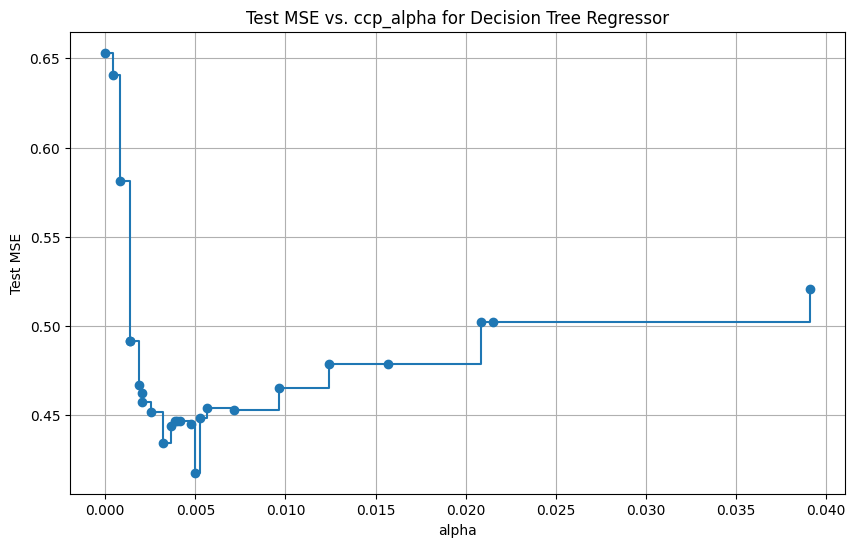

Optimal ccp_alpha: 0.005000110252495041
Minimum Test MSE at optimal alpha: 0.41778926118768495
MSE of the final pruned model: 0.41778926118768495


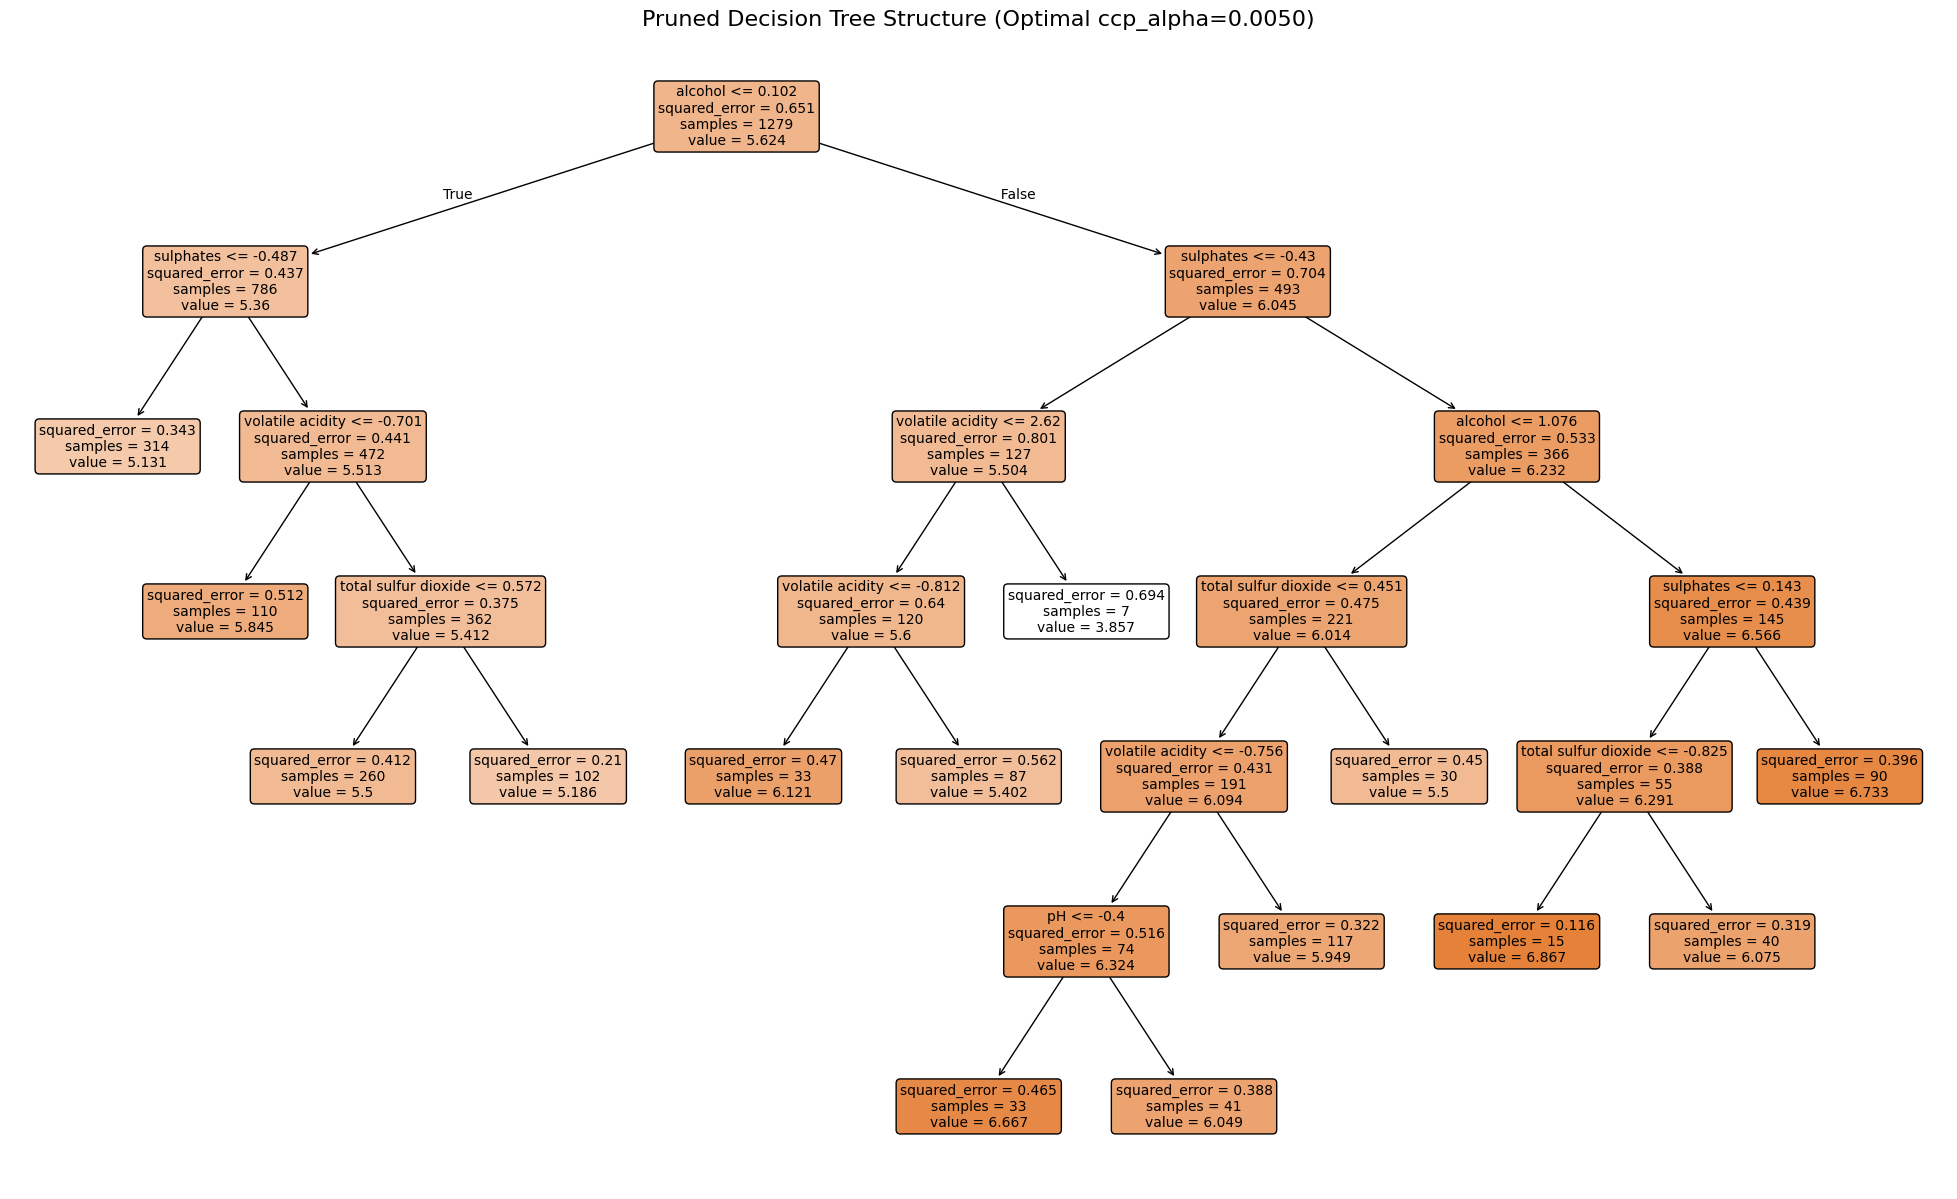

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

# 1. Load the dataset (as in previous steps)
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
df = pd.read_csv(f'{path}/winequality-red.csv')

# 2. Apply feature engineering (drop columns as previously decided)
columns_to_drop = ['fixed acidity', 'citric acid', 'chlorides', 'residual sugar', 'density']
df_processed = df.drop(columns=columns_to_drop)

# 3. Re-split the data to ensure X_train, y_train, X_test, y_test are defined from the processed df
X = df_processed.drop('quality', axis=1)
y = df_processed['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Re-define and fit the GridSearchCV pipeline (to get the best unpruned tree)
base_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid = {
    'regressor__max_depth': [3, 5, 7, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__criterion': ['squared_error', 'friedman_mse', 'absolute_error']
}

pipeline = GridSearchCV(estimator=base_pipeline,
                        param_grid=param_grid,
                        cv=5,
                        scoring='neg_mean_squared_error',
                        n_jobs=-1,
                        verbose=0)

pipeline.fit(X_train, y_train)

# Get the best unpruned DecisionTreeRegressor from the pipeline
best_unpruned_tree = pipeline.best_estimator_.named_steps['regressor']

# Get the scaler from the best pipeline to transform data for pruning path
scaler = pipeline.best_estimator_.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Calculate pruning path
path = best_unpruned_tree.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the last (max) alpha as it corresponds to a single root node tree
ccp_alphas = ccp_alphas[:-1]
impurities = impurities[:-1]

print(f"Total ccp_alphas to test: {len(ccp_alphas)}")

# 6. Train a series of trees with different ccp_alpha values
trees = []
for ccp_alpha in ccp_alphas:
    regressor = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)
    regressor_pipeline = Pipeline([
        ('scaler', StandardScaler()), # Use a fresh scaler for each tree if not pre-scaled
        ('regressor', regressor)
    ])
    regressor_pipeline.fit(X_train, y_train)
    trees.append(regressor_pipeline)

# 7. Evaluate performance of each tree on the test set
test_mses = []
for tree_pipeline in trees:
    y_pred = tree_pipeline.predict(X_test)
    test_mses.append(mean_squared_error(y_test, y_pred))

# 8. Visualize performance (MSE vs ccp_alpha)
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, test_mses, marker='o', drawstyle="steps-post")
plt.xlabel("alpha")
plt.ylabel("Test MSE")
plt.title("Test MSE vs. ccp_alpha for Decision Tree Regressor")
plt.grid(True)
plt.show()

# 9. Select optimal alpha (alpha minimizing test MSE)
optimal_alpha_idx = np.argmin(test_mses)
optimal_ccp_alpha = ccp_alphas[optimal_alpha_idx]
print(f"Optimal ccp_alpha: {optimal_ccp_alpha}")
print(f"Minimum Test MSE at optimal alpha: {test_mses[optimal_alpha_idx]}")

# 10. Train the final pruned tree with optimal alpha
final_pruned_regressor = DecisionTreeRegressor(random_state=42, ccp_alpha=optimal_ccp_alpha)
final_pruned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', final_pruned_regressor)
])
final_pruned_pipeline.fit(X_train, y_train)

y_pred_pruned = final_pruned_pipeline.predict(X_test)
final_pruned_mse = mean_squared_error(y_test, y_pred_pruned)

print(f"MSE of the final pruned model: {final_pruned_mse}")

# Get feature names from X_train (updated after column removal)
feature_names = X_train.columns.tolist()

# Get class names from y_train (unique quality levels) - still useful for visualization as 'value' display
class_names = [str(int(c)) for c in sorted(y_train.unique())] # for classification-like representation

# 11. Visualize the pruned tree
plt.figure(figsize=(25, 15)) # Adjust figure size as needed
plot_tree(final_pruned_regressor,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title(f'Pruned Decision Tree Structure (Optimal ccp_alpha={optimal_ccp_alpha:.4f})', fontsize=16)
plt.show()

/tmp/ipykernel_32503/906034524.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pruned_feature_importances.values, y=pruned_feature_importances.index, palette='magma')


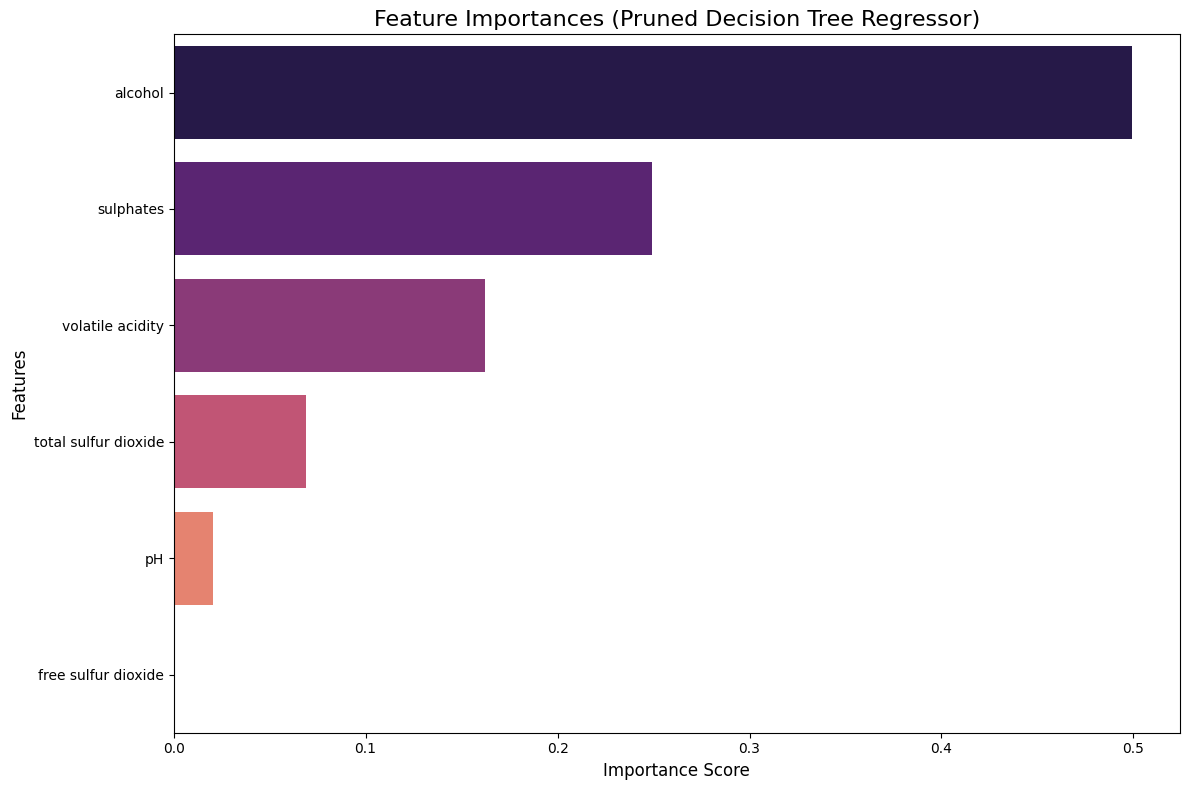

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the final pruned regressor
pruned_importances = final_pruned_regressor.feature_importances_

# Create a pandas Series for better visualization, using updated X_train.columns
pruned_feature_importances = pd.Series(pruned_importances, index=X_train.columns).sort_values(ascending=False)

# Plotting the pruned feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=pruned_feature_importances.values, y=pruned_feature_importances.index, palette='magma')
plt.title('Feature Importances (Pruned Decision Tree Regressor)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## Comparison of Feature Importances (Unpruned vs. Pruned Model)

After applying cost-complexity pruning, it's insightful to compare the feature importances of the pruned tree with those of the original, unpruned tree. While the overall ranking of features might remain similar (e.g., 'alcohol' often retaining its top position), pruning can sometimes:

*   **Reduce the importance of less influential features:** Features that were marginally useful in complex branches of the unpruned tree might see their importance diminish or become zero in the pruned tree, as those branches are removed.
*   **Sharpen the focus on truly critical features:** By removing noise and less robust splits, the pruned tree might more clearly highlight the most consistently important predictors.
*   **Provide a more stable and generalizable view of importance:** A simpler tree derived through pruning is often less prone to capturing idiosyncratic patterns in the training data, leading to feature importances that are more representative of the underlying data-generating process.

Observe the plotted feature importances above for the pruned model and compare them with the importances from the unpruned model (which was generated earlier). You might notice subtle shifts in the relative importance scores, especially for features that were originally lower in rank.

In [11]:
from sklearn.metrics import accuracy_score
import numpy as np

# --- Accuracy of the unpruned model (from earlier in the notebook) ---
# The y_pred_tuned (continuous predictions from unpruned model) and y_test should be available
# Re-calculate y_pred_tuned_rounded to ensure consistency
y_pred_tuned_unpruned = pipeline.best_estimator_.predict(X_test)
y_pred_tuned_unpruned_rounded = np.round(y_pred_tuned_unpruned).astype(int)

# Clip predictions to the range of actual quality scores (3-8 for this dataset)
min_quality, max_quality = y_test.min(), y_test.max()
y_pred_tuned_unpruned_rounded_clipped = np.clip(y_pred_tuned_unpruned_rounded, min_quality, max_quality)

accuracy_unpruned = accuracy_score(y_test, y_pred_tuned_unpruned_rounded_clipped)
print(f"Accuracy of the unpruned decision tree: {accuracy_unpruned:.4f}")

# --- Accuracy of the pruned model ---
# The y_pred_pruned (continuous predictions from pruned model) and y_test should be available
# This y_pred_pruned comes from final_pruned_pipeline.predict(X_test)
# We need to round and clip it for accuracy calculation
y_pred_pruned_rounded = np.round(y_pred_pruned).astype(int)
y_pred_pruned_rounded_clipped = np.clip(y_pred_pruned_rounded, min_quality, max_quality)

accuracy_pruned = accuracy_score(y_test, y_pred_pruned_rounded_clipped)
print(f"Accuracy of the pruned decision tree:   {accuracy_pruned:.4f}")

# --- Calculate and display the difference ---
accuracy_difference = accuracy_pruned - accuracy_unpruned
print(f"\nAccuracy difference (Pruned - Unpruned): {accuracy_difference:.4f}")

if accuracy_difference > 0:
    print("The pruned model shows a higher accuracy.")
elif accuracy_difference < 0:
    print("The unpruned model shows a higher accuracy.")
else:
    print("Both models have the same accuracy.")


Accuracy of the unpruned decision tree: 0.5625
Accuracy of the pruned decision tree:   0.5656

Accuracy difference (Pruned - Unpruned): 0.0031
The pruned model shows a higher accuracy.


## Making Real-Time Predictions with the Pruned Model

To use your `final_pruned_pipeline` for real-time predictions on new data, you need to ensure that the new data point(s) have the same features (columns) as your training data, and they should be passed to the pipeline. The pipeline internally handles the scaling of features and then makes the prediction using the best pruned regressor.

Here's how you would do it:

In [12]:
import pandas as pd
import numpy as np

# Assuming 'final_pruned_pipeline' is already trained and available in the kernel
# from the previous cells.

# Define a new, unseen wine sample for prediction.
# IMPORTANT: The features must be in the same order and use the same names
# as the X_train used during model training.
# Original features after dropping: ['volatile acidity', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates', 'alcohol']

new_wine_sample = pd.DataFrame([
    {
        'volatile acidity': 0.35,      # Example value
        'free sulfur dioxide': 15.0,   # Example value
        'total sulfur dioxide': 40.0,  # Example value
        'pH': 3.25,                    # Example value
        'sulphates': 0.75,             # Example value
        'alcohol': 11.5                # Example value
    }
])

# Make a prediction using the final pruned pipeline
predicted_quality_continuous = final_pruned_pipeline.predict(new_wine_sample)
predicted_quality_rounded = np.round(predicted_quality_continuous).astype(int)

# Optionally, clip the rounded prediction to the known quality range (3-8)
min_known_quality = 3 # Based on your dataset's min quality
max_known_quality = 8 # Based on your dataset's max quality
predicted_quality_clipped = np.clip(predicted_quality_rounded, min_known_quality, max_known_quality)

print(f"New wine sample features:\n{new_wine_sample.iloc[0].to_dict()}")
print(f"\nPredicted wine quality (continuous): {predicted_quality_continuous[0]:.2f}")
print(f"Predicted wine quality (rounded): {predicted_quality_rounded[0]}")
print(f"Predicted wine quality (rounded and clipped to [3,8]): {predicted_quality_clipped[0]}")

# Example with another sample
new_wine_sample_2 = pd.DataFrame([
    {
        'volatile acidity': 0.8,
        'free sulfur dioxide': 8.0,
        'total sulfur dioxide': 20.0,
        'pH': 3.4,
        'sulphates': 0.5,
        'alcohol': 9.0
    }
])

predicted_quality_continuous_2 = final_pruned_pipeline.predict(new_wine_sample_2)
predicted_quality_rounded_2 = np.round(predicted_quality_continuous_2).astype(int)
predicted_quality_clipped_2 = np.clip(predicted_quality_rounded_2, min_known_quality, max_known_quality)

print(f"\n\nSecond wine sample features:\n{new_wine_sample_2.iloc[0].to_dict()}")
print(f"\nPredicted wine quality (continuous): {predicted_quality_continuous_2[0]:.2f}")
print(f"Predicted wine quality (rounded): {predicted_quality_rounded_2[0]}")
print(f"Predicted wine quality (rounded and clipped to [3,8]): {predicted_quality_clipped_2[0]}")

New wine sample features:
{'volatile acidity': 0.35, 'free sulfur dioxide': 15.0, 'total sulfur dioxide': 40.0, 'pH': 3.25, 'sulphates': 0.75, 'alcohol': 11.5}

Predicted wine quality (continuous): 6.67
Predicted wine quality (rounded): 7
Predicted wine quality (rounded and clipped to [3,8]): 7


Second wine sample features:
{'volatile acidity': 0.8, 'free sulfur dioxide': 8.0, 'total sulfur dioxide': 20.0, 'pH': 3.4, 'sulphates': 0.5, 'alcohol': 9.0}

Predicted wine quality (continuous): 5.13
Predicted wine quality (rounded): 5
Predicted wine quality (rounded and clipped to [3,8]): 5
